
# Day 38 — Artificial Neural Networks (ANN)
## ANN Overview + Full ANN Training Cycle Hands-On



# 📌 Learning Goals

By the end of this notebook, you will understand:

- What ANN is
- Structure of Neural Networks
- Weights & Bias
- Activation Functions
- Forward Propagation
- Backpropagation
- Optimizers
- Complete ANN Training Cycle



# 🧠 What is ANN?

Artificial Neural Network (ANN) is a machine learning model inspired by the human brain.

It learns patterns from data using interconnected neurons.



# 🏗️ ANN Architecture

```text
Input Layer → Hidden Layer(s) → Output Layer
```



# ⚡ Mathematical Working of Neuron

Weighted Sum:

\[
z = w_1x_1 + w_2x_2 + b
\]

Activation:

\[
a = f(z)
\]



# 🔄 Full ANN Learning Cycle

```text
1. Input Data
2. Forward Propagation
3. Prediction
4. Calculate Loss
5. Backpropagation
6. Update Weights
7. Repeat
```



# 🛠️ Hands-On — Full ANN Training Cycle


In [1]:

!pip install tensorflow pandas numpy scikit-learn matplotlib


Defaulting to user installation because normal site-packages is not writeable


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


In [3]:

data = {
    'Age': [22,25,47,52,46,56,48,55,60,61],
    'Salary': [25000,30000,80000,90000,75000,100000,85000,95000,120000,130000],
    'Experience': [1,2,10,12,9,15,11,14,18,20],
    'Purchased': [0,0,1,1,1,1,1,1,1,1]
}

df = pd.DataFrame(data)

df


,Age,Salary,Experience,Purchased
0,22,25000,1,0
1,25,30000,2,0
2,47,80000,10,1
3,52,90000,12,1
4,46,75000,9,1
5,56,100000,15,1
6,48,85000,11,1
7,55,95000,14,1
8,60,120000,18,1
9,61,130000,20,1


In [4]:

X = df[['Age', 'Salary', 'Experience']]
y = df['Purchased']


In [5]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [6]:

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [7]:

model = Sequential()

model.add(Dense(
    units=8,
    activation='relu',
    input_dim=3
))

model.add(Dense(
    units=4,
    activation='relu'
))

model.add(Dense(
    units=1,
    activation='sigmoid'
))


C:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [11]:

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=2,
    validation_split=0.2
)


Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 1.0000 - loss: 0.4385 - val_accuracy: 1.0000 - val_loss: 0.5149
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 1.0000 - loss: 0.4343 - val_accuracy: 1.0000 - val_loss: 0.5113
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 1.0000 - loss: 0.4309 - val_accuracy: 1.0000 - val_loss: 0.5074
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 1.0000 - loss: 0.4271 - val_accuracy: 1.0000 - val_loss: 0.5035
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 1.0000 - loss: 0.4233 - val_accuracy: 1.0000 - val_loss: 0.4997
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 1.0000 - loss: 0.4193 - val_accuracy: 1.0000 - val_loss: 0.4960
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 1.0000 - loss: 0.4158 - val_accuracy: 1.0000 - val_loss: 0.4922
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 1.0000 - loss: 0.4122 - val_accuracy: 1.0000 - val_loss: 0.4883


In [12]:

loss, accuracy = model.evaluate(X_test, y_test)

print('Loss:', loss)
print('Accuracy:', accuracy)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 1.0000 - loss: 0.1882
Loss: 0.18821626901626587
Accuracy: 1.0


In [16]:

sample = np.array([[23, 24000, 1]])

sample = scaler.transform(sample)

prediction = model.predict(sample)

print(prediction)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
[[0.21546094]]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


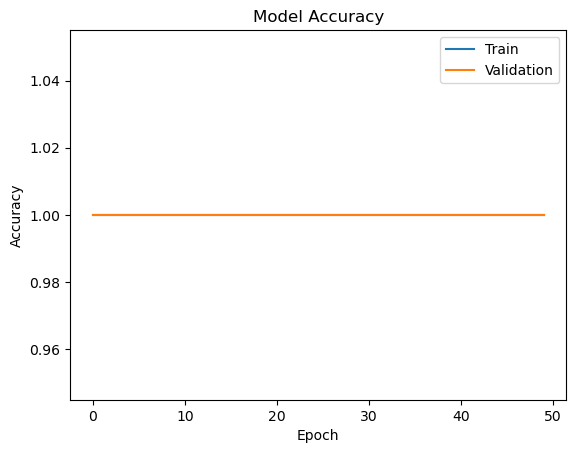

In [14]:

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])
plt.show()


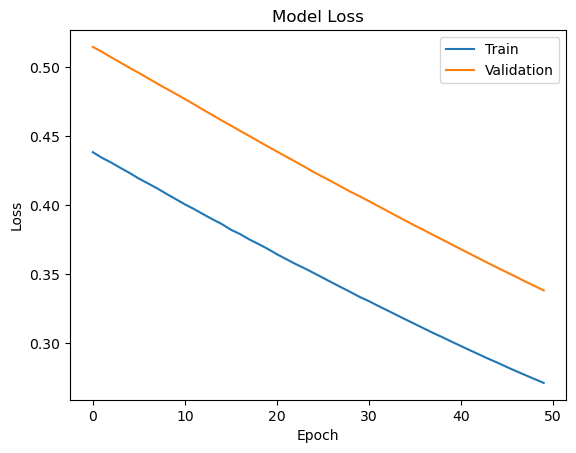

In [15]:

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train', 'Validation'])
plt.show()



# 🎯 Final Summary

ANN:

- Receives data
- Learns patterns
- Uses weights and activation functions
- Calculates loss
- Updates weights using backpropagation
- Improves predictions over time

Foundation of:

- Deep Learning
- CNN
- RNN
- Transformers
- Modern AI Systems
